<a href="https://colab.research.google.com/github/sandya-1210/Predictive_Analytics/blob/main/student_performance_model_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Study_Hours  Attendance  Previous_Marks  Assignment_Marks  Sleep_Hours  \
0            7          80              43                68            4   
1            4          68              61                57            4   
2            8          93              41                70            4   
3            5          88              49                69            8   
4            7          76              44                91            9   

   Performance  
0            1  
1            0  
2            1  
3            1  
4            1  
Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
Accuracy: 0.94
Confusion Matrix:
[[22  4]
 [ 2 72]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.85      0.88        26
           1       0.95      0.97      0.96        74

    accuracy                           0.94       100
   macro avg       0.93      0.91      0.92       100
weighted 

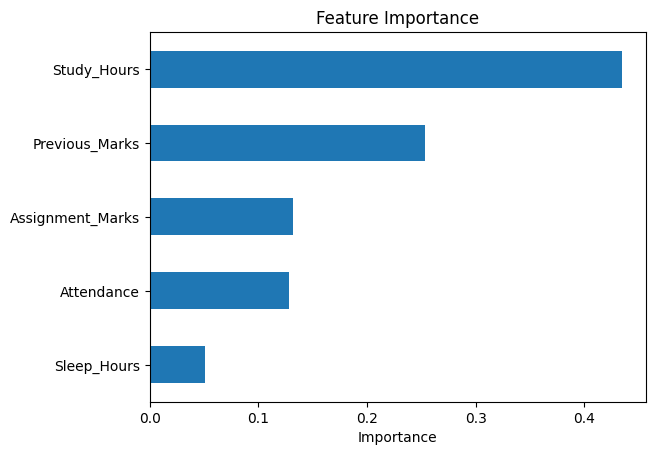

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)

n = 500

data = pd.DataFrame({
    "Study_Hours": np.random.randint(1, 10, n),
    "Attendance": np.random.randint(50, 101, n),
    "Previous_Marks": np.random.randint(40, 101, n),
    "Assignment_Marks": np.random.randint(40, 101, n),
    "Sleep_Hours": np.random.randint(4, 10, n)
})

score = (
    data["Study_Hours"] * 5 +
    data["Attendance"] * 0.3 +
    data["Previous_Marks"] * 0.4 +
    data["Assignment_Marks"] * 0.3 +
    data["Sleep_Hours"] * 2
)

data["Performance"] = np.where(score >= 100, 1, 0)

print(data.head())

X = data.drop("Performance", axis=1)
y = data["Performance"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)

parameters = {
    "n_estimators": [50, 100, 150],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    model,
    parameters,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

y_pred = grid.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

importance = pd.Series(
    grid.best_estimator_.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()